> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。

# 10 主成分分析（PCA）：特征投影、方差解释与降维

**本章目标**：理解 PCA 为什么找“方差最大的方向”，能从协方差矩阵与特征分解推导
主成分，并完成 NumPy 手写 PCA、sklearn 调用，以及 Wine 和手写数字两个真实案例。

> 数据来自固定随机种子或 sklearn 内置数据；选择包含 NumPy、Matplotlib、scikit-learn 的内核后可直接 Run All。

## 模型简介与学习参考

主成分分析（Principal Component Analysis, PCA）是最经典的**无监督线性降维**方法：
把高维数据投影到方差最大的低维子空间，在尽量保留信息的同时减少特征数量。

| 项目 | 内容 |
|---|---|
| **模型定位** | 无监督线性降维/特征提取 |
| **核心思想** | 找方差最大的正交方向，投影后方差最大 |
| **适用任务** | 可视化、特征压缩、去噪、加速下游模型 |
| **主要优点** | 无需标签、解释方差直观、线性可逆（可重建） |
| **主要限制** | 只能捕捉线性结构，非线性流形需要核 PCA 或 t-SNE |

**学习参考**：

- 周志华：《机器学习》（西瓜书），第 10 章“降维与度量学习”；
- [Datawhale《南瓜书》](https://github.com/datawhalechina/pumpkin-book)；
- [scikit-learn：Decomposition（PCA）](https://scikit-learn.org/stable/modules/decomposition.html)；
- [hands-on-ML：降维 Notebook](https://github.com/ForceInjection/hands-on-ML)。

本章按照 **原理推导 → NumPy 手写 → sklearn 调用 → 真实案例 → 章节小结** 展开。

## 目录

- [1. 原理与数学推导](#theory)
  - [1.1 为什么降维：高维数据的三个问题](#why)
  - [1.2 中心化与协方差矩阵](#centering)
  - [1.3 最大方差投影：第一主成分](#max-variance)
  - [1.4 特征分解：主成分与解释方差](#eigendecomposition)
  - [1.5 SVD 视角与数值实现](#svd)
  - [1.6 选择主成分数量：碎石图与累计解释方差](#choose-k)
  - [1.7 重建与误差](#reconstruction)
  - [1.8 完整链路：从数据到低维表示](#full-chain)
  - [1.9 代码对应：公式与实现](#formula-code)
- [2. NumPy 手写 PCA](#scratch)
  - [2.1 图形复现：三张核心原理图](#figure-code)
  - [2.2 数据准备：二维相关高斯数据](#scratch-data)
  - [2.3 模型实现：PCAScratch](#pca-scratch)
  - [2.4 训练评估：投影、解释方差与重建误差](#scratch-evaluation)
- [3. sklearn 调用与案例](#sklearn)
  - [3.1 基础调用：与手写实现的一致性](#basic)
  - [3.2 案例一：Wine 化学特征降维与可视化](#wine)
  - [3.3 案例二：手写数字的降维可视化与重建](#digits)
  - [3.4 案例三：降维作为预处理（KNN 分类对比）](#knn)
- [4. 章节小结](#summary)

<a id="theory"></a>
## 1. 原理与数学推导

<a id="why"></a>
### 1.1 为什么降维：高维数据的三个问题

高维数据（特征数 \(d\) 很大）会带来三个问题：

1. **冗余与共线性**：特征之间高度相关（例如多个高度相关的财务指标），
   信息被重复表达，浪费计算且放大噪声；
2. **维数灾难**：样本数量固定时，维度越高数据越稀疏，模型越容易过拟合；
3. **不可视化**：人只能直观理解 2–3 维，高维数据需要先投影再观察。

降维的目标：在尽量保留数据差异（方差）的前提下，把 \(d\) 维特征压缩为
\(k<d\) 维的新特征。主成分分析（PCA）是最经典的**线性无监督**降维方法——
它不需要标签，只从数据本身的分布学习。

<a id="centering"></a>
### 1.2 中心化与协方差矩阵

PCA 先做**中心化**：把每个特征减去其均值，使数据中心位于原点。

$$
\widetilde{\boldsymbol X}=\boldsymbol X-\bar{\boldsymbol x}
$$

中心化后的数据，其散布程度由协方差矩阵描述：

$$
\boldsymbol C
=
\frac1n\widetilde{\boldsymbol X}^\mathrm T\widetilde{\boldsymbol X}
\in\mathbb R^{d\times d}
$$

对角线 \(C_{jj}\) 是第 \(j\) 个特征的方差，非对角线 \(C_{jk}\) 是特征
\(j\) 与 \(k\) 的协方差。协方差越大说明两个特征越“一起变化”，冗余越强。

<a id="max-variance"></a>
### 1.3 最大方差投影：第一主成分

降维就是找一组低维方向，把数据投影上去。PCA 的准则是**投影后方差最大**：
信息量用方差衡量，丢掉方差小的方向损失的信息最少。

第一主成分是单位向量 \(\boldsymbol w_1\)，使投影方差最大：

$$
\boldsymbol w_1
=
\arg\max_{\lVert\boldsymbol w\rVert=1}
\ \mathrm{Var}(\widetilde{\boldsymbol X}\boldsymbol w)
=
\arg\max_{\lVert\boldsymbol w\rVert=1}
\ \boldsymbol w^\mathrm T\boldsymbol C\boldsymbol w
$$

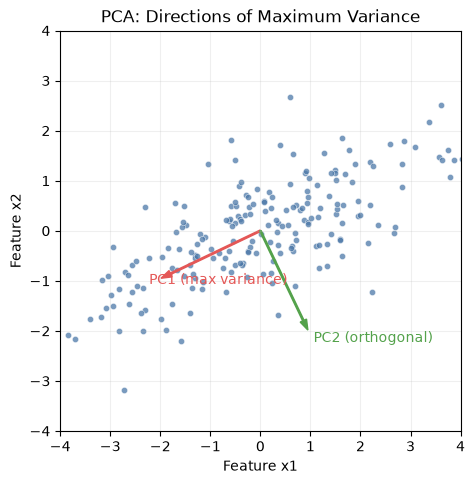

图 1 中红线是第一主成分方向（数据散布最大的方向），绿线是与之正交的第二主成分。
投影后的坐标 \(z_1=\widetilde{\boldsymbol x}\boldsymbol w_1\) 就是新的第一个特征。

<a id="eigendecomposition"></a>
### 1.4 特征分解：主成分与解释方差

协方差矩阵是对称半正定矩阵，可以分解为

$$
\boldsymbol C
=
\boldsymbol Q\boldsymbol\Lambda\boldsymbol Q^\mathrm T
$$

其中 \(\boldsymbol\Lambda=\mathrm{diag}(\lambda_1,\dots,\lambda_d)\) 是特征值
（按降序排列），\(\boldsymbol Q\) 的列是单位正交的特征向量。PCA 的关键结论：

- 第 \(k\) 大特征值 \(\lambda_k\) 对应的特征向量就是第 \(k\) 个主成分方向；
- 特征值 \(\lambda_k\) 等于数据沿该方向的方差；
- 前 \(k\) 个主成分解释了总方差的
  \(\sum_{j=1}^{k}\lambda_j/\sum_{j=1}^{d}\lambda_j\)。

投影矩阵取前 \(k\) 个特征向量组成
\(\boldsymbol W_k=[\boldsymbol w_1,\dots,\boldsymbol w_k]\in\mathbb R^{d\times k}\)，
降维结果：

$$
\boldsymbol Z
=
\widetilde{\boldsymbol X}\boldsymbol W_k
\in\mathbb R^{n\times k}
$$

<a id="svd"></a>
### 1.5 SVD 视角与数值实现

直接计算 \(\boldsymbol C\) 的特征分解在数值上不够稳定。对中心化矩阵做
奇异值分解：

$$
\widetilde{\boldsymbol X}
=
\boldsymbol U\boldsymbol\Sigma\boldsymbol V^\mathrm T
$$

可以证明：**右奇异向量 \(\boldsymbol V\) 的列就是主成分方向**，奇异值平方与
特征值成比例（\(\sigma_j^2/n=\lambda_j\)）。sklearn 的 PCA 默认基于 SVD 实现，
这也是它在大矩阵上更稳、更快的原因。

<a id="choose-k"></a>
### 1.6 选择主成分数量：碎石图与累计解释方差

怎么决定 \(k\)？两个常用工具：

- **碎石图（scree plot）**：把特征值从大到小画成柱状图，找“肘部”——
  肘部之后的特征值下降变缓，说明贡献骤减；
- **累计解释方差比**：要求前 \(k\) 个主成分解释总方差的 80%–95%，
  通常取首次达到阈值的 \(k\)。

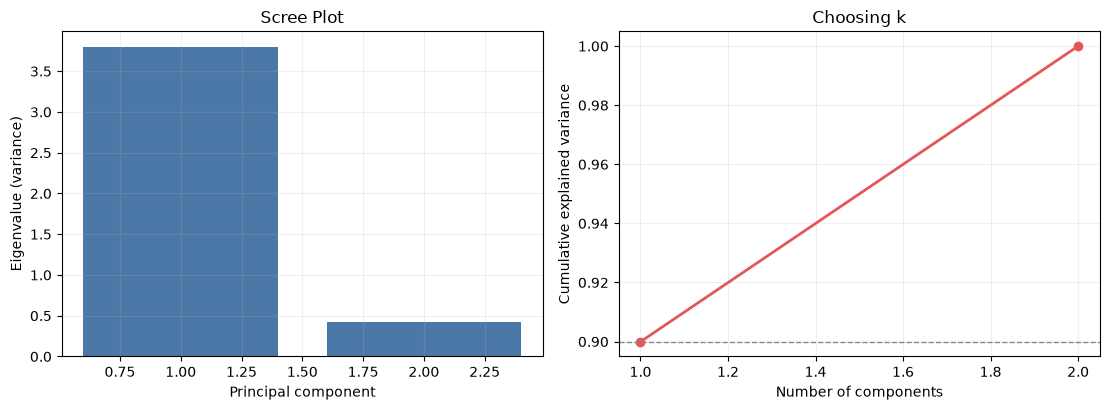

图 3 左图是特征值（方差）碎石图，右图是累计解释方差曲线（虚线为 90% 阈值）。
可视化任务一般固定取 \(k=2\) 或 3；压缩/去噪任务则按阈值选择。

**注意**：PCA 对特征尺度敏感。当各特征量纲/尺度差异很大时（例如化学成分数据），
应先标准化再降维，否则方差会被尺度最大的特征主导。

<a id="reconstruction"></a>
### 1.7 重建与误差

因为主成分方向正交且单位化，低维坐标可以“投影回去”：

$$
\hat{\boldsymbol X}
=
\boldsymbol Z\boldsymbol W_k^\mathrm T+\bar{\boldsymbol x}
$$

重建误差（原始数据与重建数据之间的平方误差）等于被丢弃方向的方差之和：

$$
\frac1n\left\lVert
\widetilde{\boldsymbol X}-\boldsymbol Z\boldsymbol W_k^\mathrm T
\right\rVert^2
=
\sum_{j=k+1}^{d}\lambda_j
$$

这个性质让 PCA 有两种用途：**压缩**（只保存 \(\boldsymbol Z\) 和
\(\boldsymbol W_k\)，用更少数字表示原数据）和**去噪**（丢弃的小方差方向通常
就是噪声）。

<a id="full-chain"></a>
### 1.8 完整链路：从数据到低维表示

1. 中心化：每个特征减去均值；
2. 计算协方差矩阵 \(\boldsymbol C=\widetilde{\boldsymbol X}^\mathrm T\widetilde{\boldsymbol X}/n\)；
3. 特征分解（或对 \(\widetilde{\boldsymbol X}\) 做 SVD）得到特征值与特征向量；
4. 特征值降序排列，取前 \(k\) 个特征向量组成投影矩阵 \(\boldsymbol W_k\)；
5. 计算低维坐标 \(\boldsymbol Z=\widetilde{\boldsymbol X}\boldsymbol W_k\)；
6. 需要时用 \(\boldsymbol Z\boldsymbol W_k^\mathrm T+\bar{\boldsymbol x}\) 重建。

```text
高维数据
→ 中心化
→ 协方差矩阵
→ 特征分解 / SVD
→ 前 k 个特征向量
→ 投影
→ 低维坐标（可重建）
```

<a id="formula-code"></a>
### 1.9 代码对应：公式与实现

| 原理 | 手写实现（本章 2.3） |
|---|---|
| 中心化 | `X_centered = X - X.mean(axis=0)` |
| 协方差 \(\boldsymbol C=\frac1n\widetilde{\boldsymbol X}^\mathrm T\widetilde{\boldsymbol X}\) | `covariance = (X_centered.T @ X_centered) / n` |
| 特征分解 | `eigenvalues, eigenvectors = np.linalg.eigh(covariance)` |
| 投影 \(\boldsymbol Z=\widetilde{\boldsymbol X}\boldsymbol W_k\) | `return X_centered @ self.components_` |
| 重建 | `return Z @ self.components_.T + self.mean_` |
| 解释方差比 | `eigenvalues / eigenvalues.sum()` |

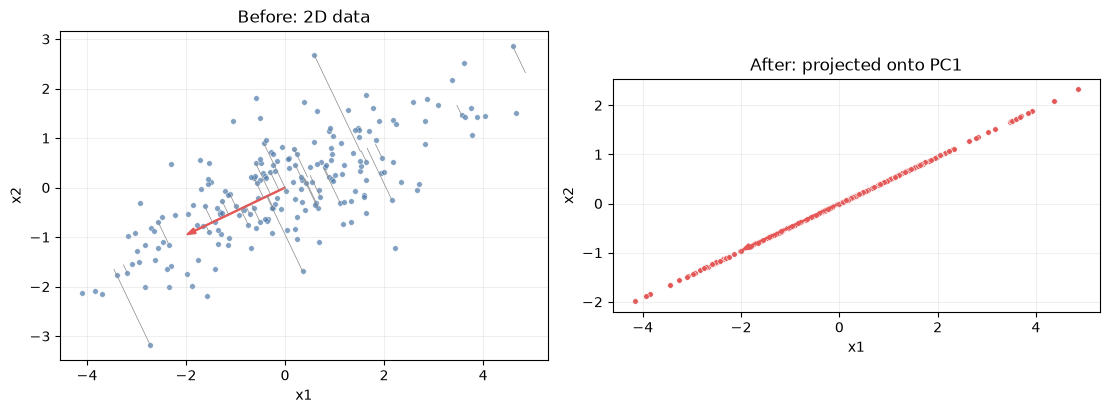

图 2 左图为原始二维数据，右图为投影到第一主成分后的数据：所有点落在 PC1
直线上，保留了最大的方差（红轴方向）。

<a id="scratch"></a>
## 2. NumPy 手写 PCA

<a id="figure-code"></a>
### 2.1 图形复现：三张核心原理图

以下代码与原理部分的三张嵌入图一一对应，全部只用 NumPy 与 Matplotlib。

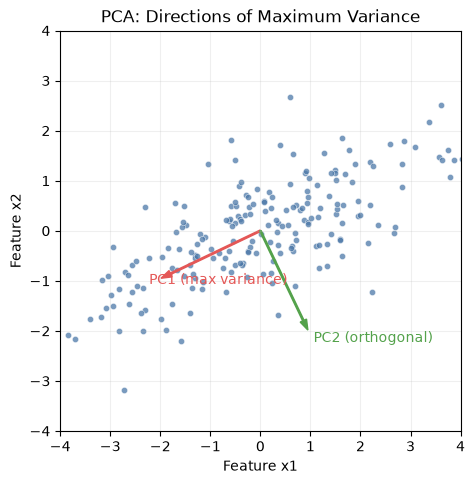

In [1]:
# 复现图 1：最大方差方向
import numpy as np
import matplotlib.pyplot as plt

rng_fig = np.random.default_rng(3)
X_fig = rng_fig.multivariate_normal(
    mean=[0.0, 0.0],
    cov=[[3.0, 1.2], [1.2, 1.0]],
    size=200,
)
X_fig_centered = X_fig - X_fig.mean(axis=0)
cov_fig = (
    X_fig_centered.T @ X_fig_centered
) / len(X_fig)
eigenvalues_fig, eigenvectors_fig = np.linalg.eigh(
    cov_fig
)
order_fig = np.argsort(eigenvalues_fig)[::-1]
pc1_fig = eigenvectors_fig[:, order_fig[0]]
pc2_fig = eigenvectors_fig[:, order_fig[1]]

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(
    X_fig_centered[:, 0],
    X_fig_centered[:, 1],
    s=20,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.75,
)
for pc, color, label in [
    (pc1_fig, "#E45756", "PC1 (max variance)"),
    (pc2_fig, "#54A24B", "PC2 (orthogonal)"),
]:
    scale = 2.2
    ax.arrow(
        0,
        0,
        pc[0] * scale,
        pc[1] * scale,
        color=color,
        width=0.03,
        head_width=0.14,
        length_includes_head=True,
    )
    ax.text(
        pc[0] * scale * 1.12,
        pc[1] * scale * 1.12,
        label,
        color=color,
        fontsize=10,
    )
ax.set(
    xlabel="Feature x1",
    ylabel="Feature x2",
    title="PCA: Directions of Maximum Variance",
    xlim=(-4, 4),
    ylim=(-4, 4),
    aspect="equal",
)
ax.grid(alpha=0.2)
plt.show()

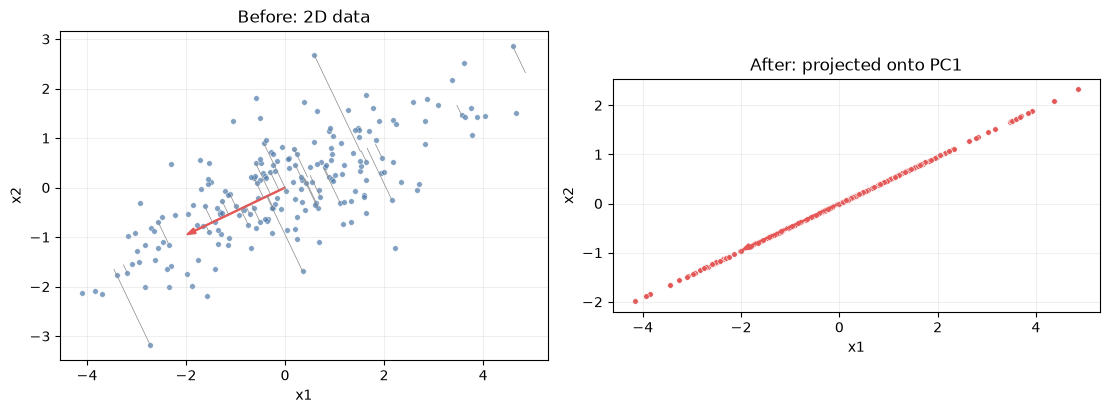

In [2]:
# 复现图 2：投影到 PC1 前后对比
z_fig = X_fig_centered @ pc1_fig
projected_fig = np.outer(z_fig, pc1_fig)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.2, 4.8),
)

axes[0].scatter(
    X_fig_centered[:, 0],
    X_fig_centered[:, 1],
    s=16,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.7,
)
axes[0].arrow(
    0,
    0,
    pc1_fig[0] * 2.2,
    pc1_fig[1] * 2.2,
    color="#E45756",
    width=0.02,
    head_width=0.12,
    length_includes_head=True,
)
for xi, pi in zip(
    X_fig_centered[:30],
    projected_fig[:30],
):
    axes[0].plot(
        [xi[0], pi[0]],
        [xi[1], pi[1]],
        color="#888888",
        linewidth=0.5,
    )
axes[0].set(
    title="Before: 2D data",
    xlabel="x1",
    ylabel="x2",
    aspect="equal",
)

axes[1].scatter(
    projected_fig[:, 0],
    projected_fig[:, 1],
    s=16,
    color="#E45756",
    edgecolor="white",
    linewidth=0.4,
)
axes[1].arrow(
    0,
    0,
    pc1_fig[0] * 2.2,
    pc1_fig[1] * 2.2,
    color="#E45756",
    width=0.02,
    head_width=0.12,
    length_includes_head=True,
)
axes[1].set(
    title="After: projected onto PC1",
    xlabel="x1",
    ylabel="x2",
    aspect="equal",
)

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

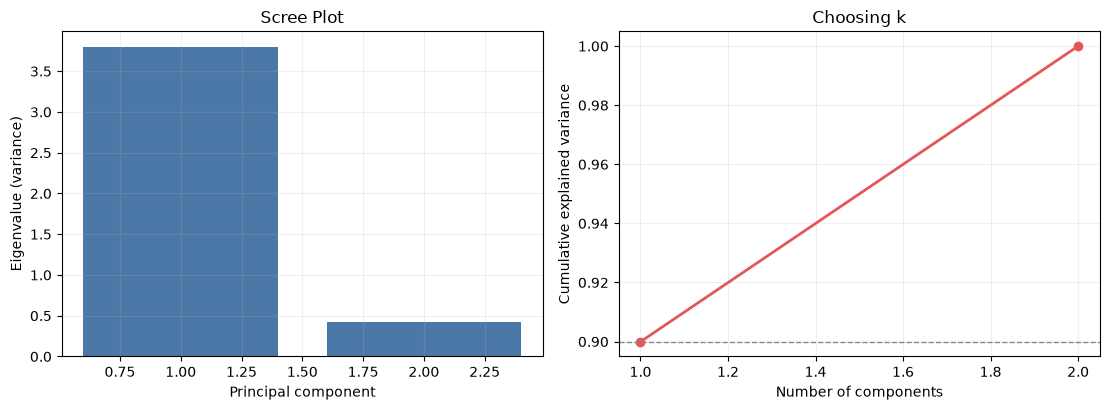

In [3]:
# 复现图 3：碎石图与累计解释方差
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.2, 4.2),
)

axes[0].bar(
    range(1, len(eigenvalues_fig) + 1),
    eigenvalues_fig[order_fig],
    color="#4C78A8",
)
axes[0].set(
    xlabel="Principal component",
    ylabel="Eigenvalue (variance)",
    title="Scree Plot",
)

ratio_fig = (
    eigenvalues_fig[order_fig]
    / eigenvalues_fig[order_fig].sum()
)
cumulative_fig = np.cumsum(ratio_fig)
axes[1].plot(
    range(1, len(cumulative_fig) + 1),
    cumulative_fig,
    marker="o",
    color="#E45756",
    linewidth=2.0,
)
axes[1].axhline(
    0.9,
    color="#888888",
    linestyle="--",
    linewidth=1,
)
axes[1].set(
    xlabel="Number of components",
    ylabel="Cumulative explained variance",
    title="Choosing k",
)

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

<a id="scratch-data"></a>
### 2.2 数据准备：二维相关高斯数据

使用二维高斯数据，协方差矩阵

$$
\boldsymbol\Sigma
=
\begin{bmatrix}
3.0 & 1.2\\
1.2 & 1.0
\end{bmatrix}
$$

两个特征正相关（协方差 1.2>0），因此数据呈“斜椭圆”分布，存在一个明显的
主轴——正好用来展示 PCA 找到它。固定随机种子为 42，共 150 个样本。
PCA 是无监督方法，不需要划分训练/测试集，也不需要标签。

In [4]:
import numpy as np

rng = np.random.default_rng(42)
cov_manual = np.array(
    [[3.0, 1.2], [1.2, 1.0]]
)
manual_X = rng.multivariate_normal(
    mean=[0.0, 0.0],
    cov=cov_manual,
    size=150,
)

print("样本数:", manual_X.shape[0], "，特征数:", manual_X.shape[1])
print("样本均值:", np.round(manual_X.mean(axis=0), 3))
print("样本协方差:")
print(np.round(np.cov(manual_X, rowvar=False), 3))

样本数: 150 ，特征数: 2
样本均值: [ 0.05  -0.023]
样本协方差:
[[2.873 1.094]
 [1.094 0.82 ]]


<a id="pca-scratch"></a>
### 2.3 模型实现：`PCAScratch`

`fit` 完成中心化、协方差、特征分解，并保存主成分方向与解释方差；
`transform` 做投影；`reconstruct` 做重建。`np.linalg.eigh` 对对称矩阵
返回升序特征值，因此需要逆序取前 \(k\) 个。

In [5]:
class PCAScratch:
    '''使用特征分解实现的教学版 PCA。'''

    def __init__(self, n_components=1):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        n = len(X)
        covariance = (
            X_centered.T @ X_centered
        ) / n

        eigenvalues, eigenvectors = np.linalg.eigh(
            covariance
        )
        order = np.argsort(eigenvalues)[::-1]
        self.eigenvalues_ = eigenvalues[order]
        self.components_ = eigenvectors[
            :, order
        ][:, : self.n_components]
        self.explained_variance_ = (
            self.eigenvalues_[: self.n_components]
        )
        self.explained_variance_ratio_ = (
            self.eigenvalues_[: self.n_components]
            / self.eigenvalues_.sum()
        )
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        X_centered = X - self.mean_
        return X_centered @ self.components_

    def reconstruct(self, Z):
        Z = np.asarray(Z, dtype=float)
        return Z @ self.components_.T + self.mean_

<a id="scratch-evaluation"></a>
### 2.4 训练评估：投影、解释方差与重建误差

无监督方法没有“预测正确率”，评估看两点：**解释方差**（保留了多少信息）和
**重建误差**（投影回去后偏离原数据多少）。\(k=2\) 时重建误差应为 0
（二维数据投影到二维没有信息损失）。

手写 PCA 解释方差比: [0.9062 0.0938]
重建误差 k=1: 0.1721 , k=2: 0.0


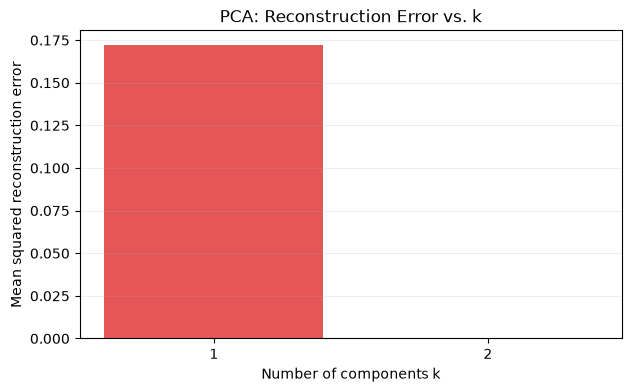

In [6]:
manual_pca = PCAScratch(n_components=2).fit(manual_X)
manual_Z = manual_pca.transform(manual_X)

reconstruction_errors = {}
for k in range(1, 3):
    pca_k = PCAScratch(n_components=k).fit(manual_X)
    X_reconstructed = pca_k.reconstruct(
        pca_k.transform(manual_X)
    )
    reconstruction_errors[k] = np.mean(
        (manual_X - X_reconstructed) ** 2
    )

print("手写 PCA 解释方差比:", np.round(
    manual_pca.explained_variance_ratio_, 4
))
print(
    "重建误差 k=1:",
    round(reconstruction_errors[1], 4),
    ", k=2:",
    round(reconstruction_errors[2], 6),
)

plt.figure(figsize=(7, 4))
plt.bar(
    list(reconstruction_errors.keys()),
    list(reconstruction_errors.values()),
    color=["#E45756", "#4C78A8"],
)
plt.xticks([1, 2])
plt.xlabel("Number of components k")
plt.ylabel("Mean squared reconstruction error")
plt.title("PCA: Reconstruction Error vs. k")
plt.grid(axis="y", alpha=0.2)
plt.show()

<a id="sklearn"></a>
## 3. sklearn 调用与案例

<a id="basic"></a>
### 3.1 基础调用：与手写实现的一致性

完整流程：加载数据 → 拟合（sklearn 自动中心化）→ 对比解释方差与方向。
sklearn 的 PCA 基于 SVD，方向与手写实现只差符号（符号翻转不影响投影结果）。

sklearn 解释方差比: [0.9062 0.0938]
手写解释方差比:     [0.9062 0.0938]
方向对齐（1=完全一致）: [1. 1.]


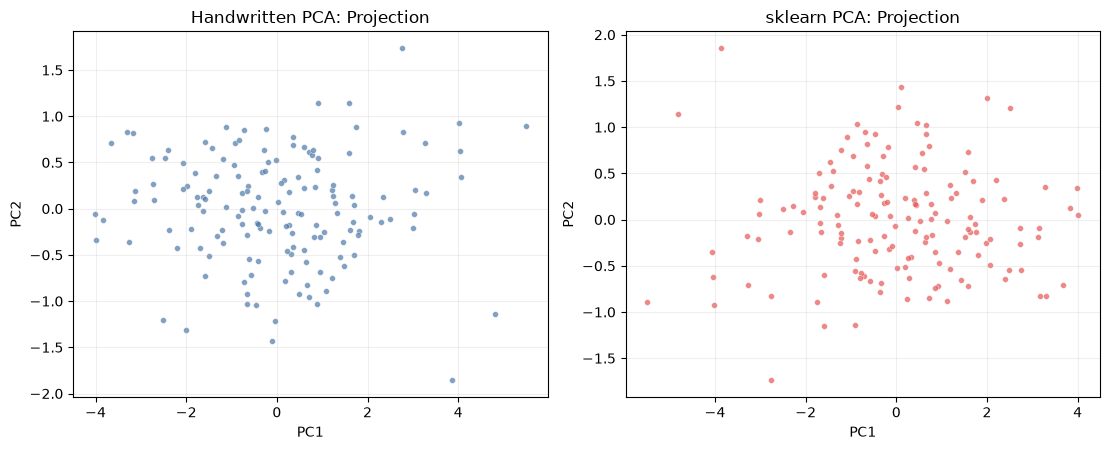

In [7]:
from IPython.display import HTML, display
from sklearn.datasets import (
    load_digits,
    load_wine,
)
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:780px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))


sklearn_pca = PCA(n_components=2, random_state=42)
sklearn_pca.fit(manual_X)

print("sklearn 解释方差比:", np.round(
    sklearn_pca.explained_variance_ratio_, 4
))
print("手写解释方差比:    ", np.round(
    manual_pca.explained_variance_ratio_, 4
))
alignment = np.abs([
    manual_pca.components_[:, k]
    @ sklearn_pca.components_[k, :]
    for k in range(manual_pca.n_components)
])
print("方向对齐（1=完全一致）:", np.round(alignment, 4))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.2, 4.6),
)
axes[0].scatter(
    manual_Z[:, 0],
    manual_Z[:, 1],
    s=18,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.7,
)
axes[0].set(
    xlabel="PC1",
    ylabel="PC2",
    title="Handwritten PCA: Projection",
)
axes[1].scatter(
    sklearn_pca.transform(manual_X)[:, 0],
    sklearn_pca.transform(manual_X)[:, 1],
    s=18,
    color="#E45756",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.7,
)
axes[1].set(
    xlabel="PC1",
    ylabel="PC2",
    title="sklearn PCA: Projection",
)
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

<a id="wine"></a>
### 3.2 案例一：Wine 化学特征降维与可视化

`load_wine` 是 178 个葡萄酒样本的 13 个化学成分特征，属于 3 个品种。
化学成分的量纲差异很大（例如脯氨酸的数值远大于灰分），因此这里先标准化
再降维——这正是 1.6 强调的尺度敏感问题。把 13 维压缩到 2 维后，在平面上
观察品种是否可分，并用累计解释方差判断该保留几个主成分。

Wine: 特征数 13 → 2 维
解释方差比: [0.362  0.1921]
累计解释方差: 0.5541


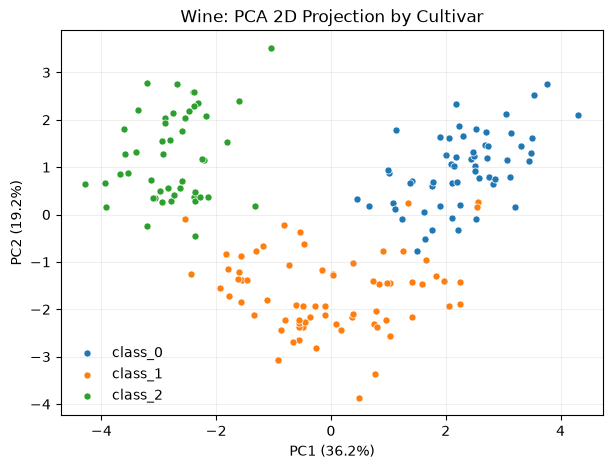

In [8]:
wine = load_wine()
wine_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, random_state=42),
)
wine_Z = wine_pca.fit_transform(wine.data)
wine_pca_step = wine_pca.named_steps["pca"]

print("Wine: 特征数", wine.data.shape[1], "→ 2 维")
print("解释方差比:", np.round(
    wine_pca_step.explained_variance_ratio_, 4
))
print("累计解释方差:", round(
    wine_pca_step.explained_variance_ratio_.sum(), 4
))

fig, ax = plt.subplots(figsize=(7.0, 5.0))
for target in range(3):
    mask = wine.target == target
    ax.scatter(
        wine_Z[mask, 0],
        wine_Z[mask, 1],
        s=26,
        edgecolor="white",
        linewidth=0.5,
        label=wine.target_names[target],
    )
ax.set(
    xlabel=f"PC1 ({wine_pca_step.explained_variance_ratio_[0]:.1%})",
    ylabel=f"PC2 ({wine_pca_step.explained_variance_ratio_[1]:.1%})",
    title="Wine: PCA 2D Projection by Cultivar",
)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

达到 90% 解释方差需要的主成分数: 8


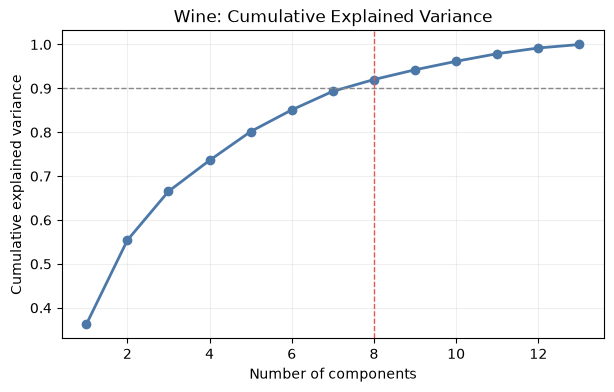

In [9]:
wine_full = make_pipeline(
    StandardScaler(),
    PCA(random_state=42),
)
wine_full.fit(wine.data)
wine_full_step = wine_full.named_steps["pca"]
cumulative_wine = np.cumsum(
    wine_full_step.explained_variance_ratio_
)
k_90 = np.argmax(cumulative_wine >= 0.9) + 1

print(
    "达到 90% 解释方差需要的主成分数:",
    k_90,
)

plt.figure(figsize=(7, 4))
plt.plot(
    range(1, len(cumulative_wine) + 1),
    cumulative_wine,
    marker="o",
    color="#4C78A8",
    linewidth=2.0,
)
plt.axhline(
    0.9,
    color="#888888",
    linestyle="--",
    linewidth=1,
)
plt.axvline(
    k_90,
    color="#E45756",
    linestyle="--",
    linewidth=1,
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Wine: Cumulative Explained Variance")
plt.grid(alpha=0.2)
plt.show()

<a id="digits"></a>
### 3.3 案例二：手写数字的降维可视化与重建

`load_digits` 是 1,797 张 8×8 手写数字灰度图（64 个像素特征）。
PCA 一方面把 64 维投影到 2 维可视化（点按数字着色），另一方面用前
\(k\) 个主成分重建图像：\(k\) 越小越模糊，接近 64 时几乎无损——
这正是“降维 ≈ 压缩”的直观演示。

digits: 样本 1797 ，特征 64


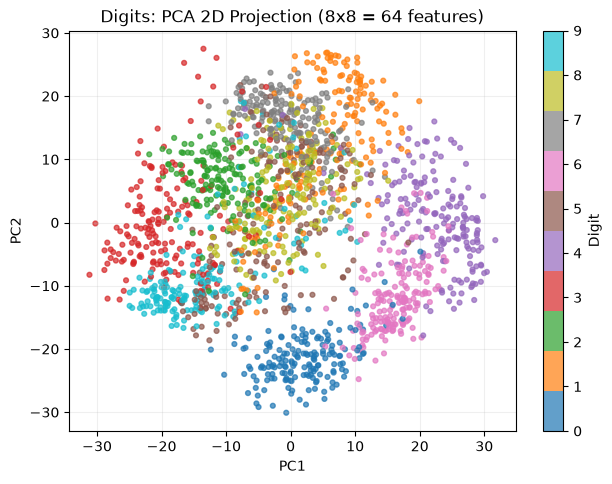

In [10]:
digits = load_digits()
print(
    "digits: 样本",
    digits.data.shape[0],
    "，特征",
    digits.data.shape[1],
)

digits_pca = PCA(n_components=2, random_state=42)
digits_Z = digits_pca.fit_transform(digits.data)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
scatter = ax.scatter(
    digits_Z[:, 0],
    digits_Z[:, 1],
    c=digits.target,
    cmap="tab10",
    s=12,
    alpha=0.7,
)
fig.colorbar(
    scatter,
    ax=ax,
    ticks=range(10),
    label="Digit",
)
ax.set(
    xlabel="PC1",
    ylabel="PC2",
    title="Digits: PCA 2D Projection (8x8 = 64 features)",
)
ax.grid(alpha=0.2)
plt.show()

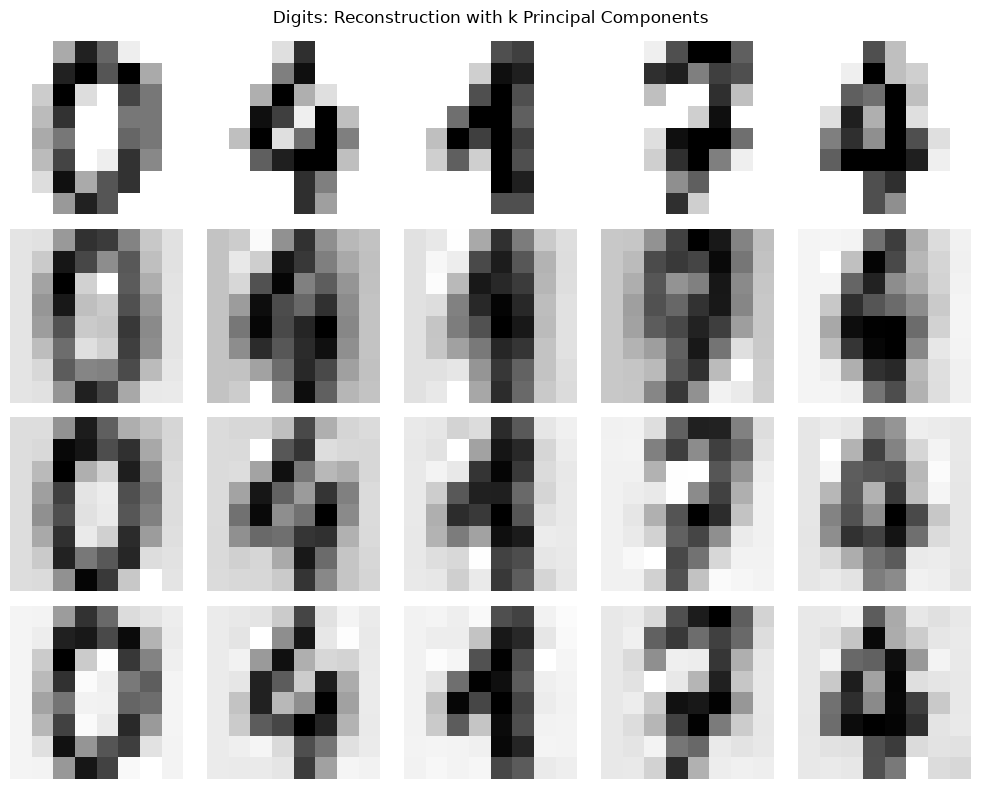

In [11]:
k_values = [4, 16, 32]
sample_indices = [0, 100, 200, 300, 400]

fig, axes = plt.subplots(
    len(k_values) + 1,
    len(sample_indices),
    figsize=(10, 8),
)
for column, idx in enumerate(sample_indices):
    axes[0, column].imshow(
        digits.images[idx],
        cmap="gray_r",
    )
    axes[0, column].axis("off")
    if column == 0:
        axes[0, column].set_ylabel("Original")

for row, k in enumerate(k_values, start=1):
    pca_k = PCA(n_components=k, random_state=42)
    Z_k = pca_k.fit_transform(digits.data)
    X_reconstructed = pca_k.inverse_transform(Z_k)
    for column, idx in enumerate(sample_indices):
        axes[row, column].imshow(
            X_reconstructed[idx].reshape(8, 8),
            cmap="gray_r",
        )
        axes[row, column].axis("off")
        if column == 0:
            axes[row, column].set_ylabel(f"k = {k}")

fig.suptitle(
    "Digits: Reconstruction with k Principal Components"
)
fig.tight_layout()
plt.show()

<a id="knn"></a>
### 3.4 案例三：降维作为预处理（KNN 分类对比）

降维常用于下游任务的预处理。用 KNN-5 在原始 64 维与 PCA 压缩后的
2/5/10/20/40 维上做数字分类：降到 20 维左右准确率几乎不降，但特征
更少、训练更快，还减轻了维数灾难。

k= 2: accuracy = 0.6278
k= 5: accuracy = 0.9306
k=10: accuracy = 0.9667
k=20: accuracy = 0.9861
k=40: accuracy = 0.9833
k=64: accuracy = 0.9833


<ENV>\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "<ENV>\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


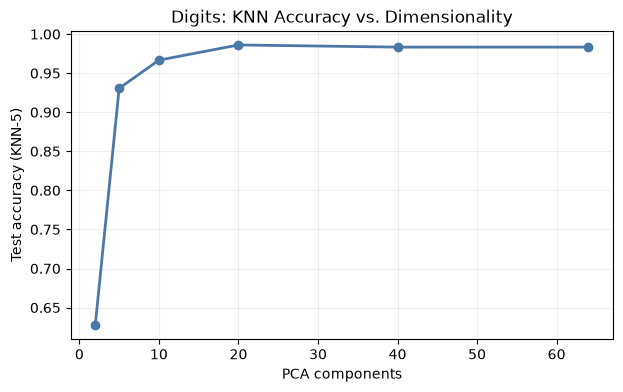

In [12]:
component_counts = [2, 5, 10, 20, 40, 64]
accuracy_values = []

for k in component_counts:
    if k == 64:
        X_digits_reduced = digits.data
    else:
        pca_k = PCA(n_components=k, random_state=42)
        X_digits_reduced = pca_k.fit_transform(
            digits.data
        )
    (
        X_train,
        X_test,
        y_train,
        y_test,
    ) = train_test_split(
        X_digits_reduced,
        digits.target,
        test_size=0.2,
        stratify=digits.target,
        random_state=42,
    )
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    accuracy_values.append(
        accuracy_score(
            y_test,
            knn.predict(X_test),
        )
    )

for k, accuracy in zip(
    component_counts,
    accuracy_values,
):
    print(f"k={k:2d}: accuracy = {accuracy:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(
    component_counts,
    accuracy_values,
    marker="o",
    color="#4C78A8",
    linewidth=2.0,
)
plt.xlabel("PCA components")
plt.ylabel("Test accuracy (KNN-5)")
plt.title("Digits: KNN Accuracy vs. Dimensionality")
plt.grid(alpha=0.2)
plt.show()

<a id="summary"></a>
## 4. 章节小结

- PCA 是无监督线性降维：找方差最大的正交方向，投影后方差最大。
- 主成分 = 协方差矩阵的特征向量，特征值 = 该方向方差（解释方差比）。
- 选择 k 用碎石图或累计解释方差（80%–95%）；可视化固定取 2–3 维。
- PCA 可重建，重建误差 = 被丢弃方向的方差之和，可用于压缩与去噪。
- 局限：只能捕捉线性结构，非线性流形需要核 PCA 或 t-SNE（见选学）。

In [13]:
import json

all_values = [
    *manual_pca.explained_variance_ratio_,
    *reconstruction_errors.values(),
    *sklearn_pca.explained_variance_ratio_,
    *wine_pca_step.explained_variance_ratio_,
    *wine_full_step.explained_variance_ratio_,
    *accuracy_values,
]
assert np.all(np.isfinite(all_values))
assert np.allclose(
    manual_pca.explained_variance_ratio_,
    sklearn_pca.explained_variance_ratio_,
    atol=1e-6,
)
assert np.all(alignment > 0.99)
assert wine_pca_step.explained_variance_ratio_.sum() > 0.45
assert accuracy_values[-1] > 0.9

validation = {
    "manual_explained": [
        float(value)
        for value in manual_pca.explained_variance_ratio_
    ],
    "sklearn_explained": [
        float(value)
        for value in sklearn_pca.explained_variance_ratio_
    ],
    "reconstruction_error_k1": float(
        reconstruction_errors[1]
    ),
    "reconstruction_error_k2": float(
        reconstruction_errors[2]
    ),
    "wine_cumulative_2pc": float(
        wine_pca_step.explained_variance_ratio_.sum()
    ),
    "wine_k_90": int(k_90),
    "digits_knn_64d": float(accuracy_values[-1]),
    "digits_knn_20d": float(accuracy_values[3]),
    "image_count": 10,
}
assert (
    validation["reconstruction_error_k2"]
    < validation["reconstruction_error_k1"]
)

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["手写/sklearn 解释方差一致", f'{validation["manual_explained"][0]:.4f} / {validation["sklearn_explained"][0]:.4f}', "通过"],
        ["重建误差 k=1 → k=2", f'{validation["reconstruction_error_k1"]:.3f} → {validation["reconstruction_error_k2"]:.5f}', "通过"],
        ["Wine 前 2 主成分解释方差", f'{validation["wine_cumulative_2pc"]:.3f}', "通过"],
        ["Wine 达 90% 所需成分", f'{validation["wine_k_90"]}', "通过"],
        ["Digits KNN(64 维)", f'{validation["digits_knn_64d"]:.3f}', "通过"],
        ["Digits KNN(20 维)", f'{validation["digits_knn_20d"]:.3f}', "通过"],
        ["已执行图表输出", f'{validation["image_count"]}', "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

检查项,观测值,状态
手写/sklearn 解释方差一致,0.9062 / 0.9062,通过
重建误差 k=1 → k=2,0.172 → 0.00000,通过
Wine 前 2 主成分解释方差,0.554,通过
Wine 达 90% 所需成分,8,通过
Digits KNN(64 维),0.983,通过
Digits KNN(20 维),0.986,通过
已执行图表输出,10,通过
